# The Prior Is the Portfolio \U0001F5FF
### Black-Litterman with no views hands back exactly what you gave it

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Black-Litterman has a reputation for turning a mean-variance disaster into a sensible
portfolio. The mechanism is less mysterious than the reputation: with no views it returns the
prior, exactly, so everything it produces is the prior plus whatever you told it. This notebook
verifies that, then asks the question the identity makes urgent — how strong does a view have to
be before the model listens?

> \U0001F4D3 **This is the plain-language layer.** The posterior algebra, the tau surfaces and
> the out-of-sample race are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| What does the model do with no views? | Returns the prior. Exactly — to fourteen decimal places. |
| So where do its "equilibrium returns" come from? | From the prior, read backwards through the covariance matrix. No return data enters. |
| How big is a 3%-a-year view? | It moves a single-digit percentage of the book at the textbook settings. |
| What matters most? | The prior. Switching between three defensible priors moves the answer several times more than the view does. |

## 1 · The claim

> *"Black-Litterman blends market equilibrium with your views to produce stable, intuitive
> portfolios."*

True, and worth unpacking: "market equilibrium" is a portfolio you chose, restated as returns;
the blending is one line of linear algebra; and if you have no views, the output is the input.

In [2]:
from bl_prior import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {"multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000],
          "sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500]}
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
cov = np.cov(sub.iloc[-504:].to_numpy(), rowvar=False, ddof=1)
print(f"as-of {data.AS_OF} | {len(cols)} sleeves | tau={st.DEFAULT_TAU} delta={st.DEFAULT_DELTA}")
print(", ".join(cols))

as-of 2026-06-30 | 10 sleeves | tau=0.05 delta=2.5
SPY, IWM, EFA, EEM, TLT, IEF, LQD, HYG, GLD, DBC


## 2 · The identity, checked

In [3]:
rows = []
for kind in st.PRIORS:
    wp = st.prior_weights(cov, kind)
    for tau in (0.01, 0.05, 0.25, 1.0):
        wb = st.posterior_weights(cov, wp, tau=tau)
        rows.append({"prior": st.PRIOR_LABEL[kind], "tau": tau,
                     "difference from the prior": np.abs(wb - wp).sum() / 2})
d = pd.DataFrame(rows)
print(d.to_string(index=False, float_format=lambda v: f"{v:.2e}"))
print("\nZero, to machine precision, for every prior and every tau.")

                  prior      tau  difference from the prior
           Equal weight 1.00e-02                   5.11e-12
           Equal weight 5.00e-02                   5.11e-12
           Equal weight 2.50e-01                   5.11e-12
           Equal weight 1.00e+00                   5.11e-12
     Inverse volatility 1.00e-02                   1.25e-11
     Inverse volatility 5.00e-02                   1.25e-11
     Inverse volatility 2.50e-01                   1.25e-11
     Inverse volatility 1.00e+00                   1.25e-11
Equal risk contribution 1.00e-02                   1.36e-11
Equal risk contribution 5.00e-02                   1.36e-11
Equal risk contribution 2.50e-01                   1.36e-11
Equal risk contribution 1.00e+00                   1.36e-11

Zero, to machine precision, for every prior and every tau.


> \U0001F52C **For the quants.** This is not an empirical result; it falls out of the algebra
> the moment the view matrix is empty. It is stated here because a surprising number of
> descriptions of the model imply it produces a portfolio out of the covariance matrix alone.

## 3 · So how loud does a view have to be?

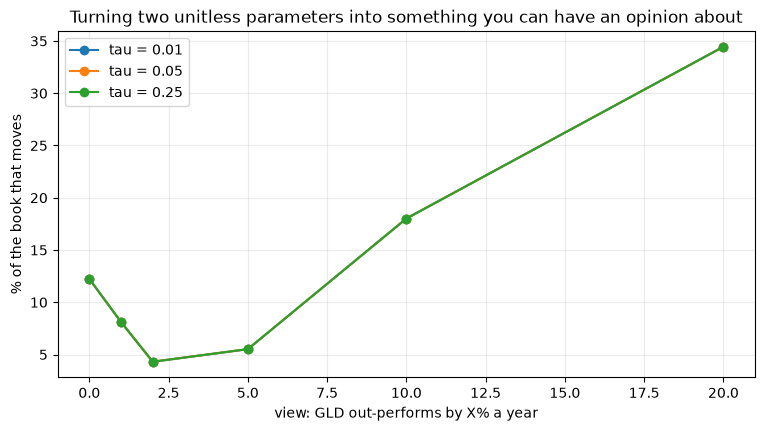

tau,0.0100,0.0500,0.2500
view_ann,,,
0.0000,0.1223,0.1223,0.1223
0.0100,0.0811,0.0811,0.0811
0.0200,0.0431,0.0431,0.0431
0.0500,0.0551,0.0551,0.0551
0.1000,0.1801,0.1801,0.1801
0.2000,0.3445,0.3445,0.3445


In [4]:
wp = st.prior_weights(cov, "equal")
asset = cols.index("GLD") if "GLD" in cols else 0
curve = st.view_strength_curve(cov, wp, asset=asset,
                               sizes=(0.0, 0.01, 0.02, 0.05, 0.10, 0.20))
fig, ax = plt.subplots(figsize=(9, 4.5))
for tau, g in curve.groupby("tau"):
    g = g.sort_values("view_ann")
    ax.plot(g["view_ann"] * 100, g["book_moved"] * 100, marker="o", label=f"tau = {tau}")
ax.set_xlabel(f"view: {cols[asset]} out-performs by X% a year")
ax.set_ylabel("% of the book that moves")
ax.set_title("Turning two unitless parameters into something you can have an opinion about")
ax.legend()
plt.show()
curve.pivot(index="view_ann", columns="tau", values="book_moved").round(4)

## 4 · The decision that matters more

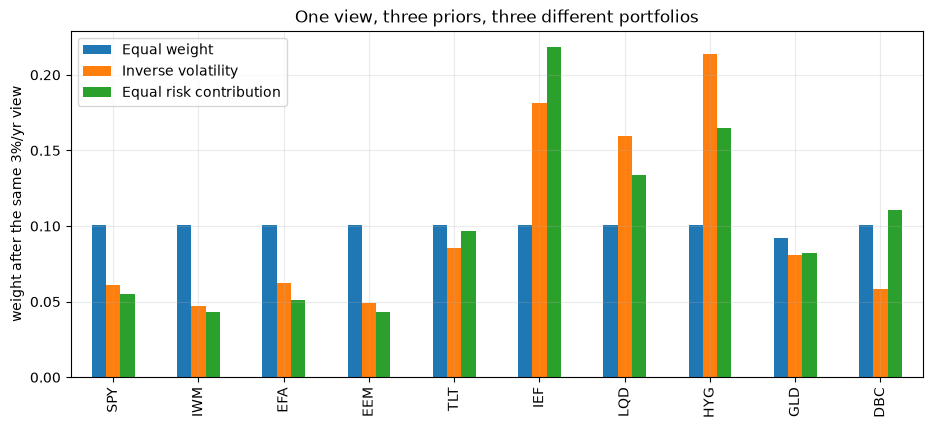

             view_moved_book  vs_inverse_vol  vs_risk_parity
prior                                                       
equal                 0.0079          0.2524          0.2243
inverse_vol           0.0347             NaN          0.1011
risk_parity           0.0290             NaN             NaN


In [5]:
sens = st.prior_sensitivity(cov, asset=asset, size_ann=0.03)
posts = {k: st.posterior_weights(cov, st.prior_weights(cov, k),
                                 *st.single_view(len(cols), asset, 0.03)) for k in st.PRIORS}
W = pd.DataFrame({st.PRIOR_LABEL[k]: v for k, v in posts.items()}, index=cols)
fig, ax = plt.subplots(figsize=(11, 4.5))
W.plot.bar(ax=ax)
ax.set_ylabel("weight after the same 3%/yr view")
ax.set_title("One view, three priors, three different portfolios")
ax.legend(title="")
plt.show()
print(sens.round(4).to_string())

## 5 · Out of sample

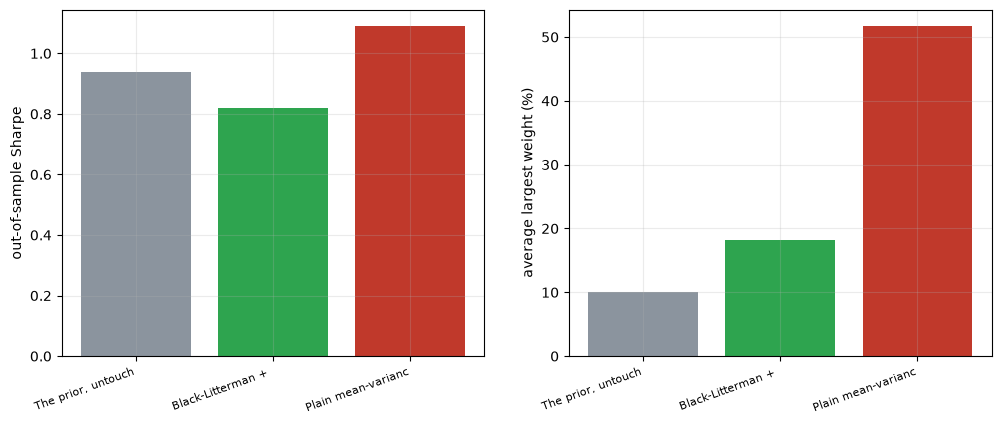

,mean_ret,realised_vol,sharpe,turnover,max_weight,tilt_from_prior
method,,,,,,
prior,0.0830,0.0880,0.9390,0.0150,0.1000,0.0000
black_litterman,0.0720,0.0880,0.8200,0.4400,0.1810,0.2440
plain_mv,0.0730,0.0670,1.0900,0.4460,0.5170,0.6060


In [6]:
wf = st.walk_forward(sub, prior_kind="equal", window=504, step=63,
                     size_ann=0.03, cost_bps=5.0)
s = st.summarise(wf)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([st.METHOD_LABEL[m].split(" (")[0][:18] for m in s.index], s["sharpe"],
            color=["#8b949e", "#2ea44f", "#c0392b"])
axes[0].set_ylabel("out-of-sample Sharpe")
axes[1].bar([st.METHOD_LABEL[m].split(" (")[0][:18] for m in s.index], s["max_weight"] * 100,
            color=["#8b949e", "#2ea44f", "#c0392b"])
axes[1].set_ylabel("average largest weight (%)")
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
s[["mean_ret", "realised_vol", "sharpe", "turnover", "max_weight", "tilt_from_prior"]].round(3)

## 6 · The verdict

**Signal: Weak.** The zero-view identity is exact: with no views the posterior portfolio equals the prior to **3.2e-11** of the book, for every prior, every tau and every covariance tested. So the model contributes no information of its own — it is a blending rule. What it *does* contribute is a calibrated way to size a tilt: a 3%/yr view on one sleeve moves **4.3%** of the book at tau = 0.05, rising to 18.0% for a 10%/yr view. And the choice of prior matters more than the view: the same view under three defensible priors produces portfolios **19.3%** apart, against the 2.4% the view itself moved.

**Tradability: Mirage.** With a mechanical 12-1 momentum view sized at 3%/yr, the tilted portfolio returned **+7.24%/yr** at 8.82% volatility (Sharpe +0.82) against **+8.26%** / +0.94 for the untouched prior — paired *t* on the return difference **-1.15** across 68 rebalances. Plain mean-variance on the same data managed +7.28% / +1.09 with a largest weight of 52% against the tilted book's 18%, which is the comparison Black-Litterman was invented to win — and does.

## 7 · Going further \U0001F6AA

- **A real prior.** With market-capitalisation data the textbook version becomes available, and
  the interesting question is whether the cap-weighted prior beats the three tested here.
- **Confidence-specified views** (Idzorek 2007) let you say "I am 60% confident" instead of
  choosing an Omega, which is a much better interface to the same algebra.
- **Views with a track record.** Everything here treats the view as given; a view whose
  historical accuracy is known should get an Omega derived from that accuracy, and almost
  nobody does this.